In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState

In [2]:
from langchain.chat_models import init_chat_model

In [3]:
model_id="gemini-2.5-flash-preview-05-20"
llm = init_chat_model(model=model_id,model_provider="google_vertexai",project="buoyant-keel-461215-a8")

In [4]:
def call_state(state: MessagesState) -> MessagesState:
    state['messages'] = llm.invoke(state['messages'])
    return state

In [5]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("llm",call_state)
graph_builder.add_edge(START,"llm")
graph_builder.add_edge("llm",END)
graph = graph_builder.compile()

In [6]:
from IPython.display import Image, display
def display_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

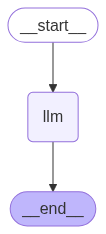

In [7]:
display_graph(graph)

In [13]:
from langchain_core.messages import SystemMessage, HumanMessage
messages =  [
    SystemMessage("You are a helpful Assistant"),
    HumanMessage("Help me Undersatnd about Netwons Laws of Physics indetail")
]
result = graph.invoke({"messages": messages})

In [14]:
result['messages']

[SystemMessage(content='You are a helpful Assistant', additional_kwargs={}, response_metadata={}, id='e5e3591e-b101-4321-9a4b-57f813d48d21'),
 HumanMessage(content='Help me Undersatnd about Netwons Laws of Physics indetail', additional_kwargs={}, response_metadata={}, id='3a0d4a37-8a75-4561-9ba8-fc8f6cad853e'),
 AIMessage(content='Sir Isaac Newton\'s three laws of motion are the bedrock of classical mechanics. They describe the relationship between an object, the forces acting upon it, and its motion. Understanding them is key to grasping how the physical world around us works, from why a ball rolls to how a rocket flies.\n\nLet\'s break down each law in detail:\n\n---\n\n## **Newton\'s First Law of Motion: The Law of Inertia**\n\n**Statement:** "An object at rest stays at rest, and an object in motion stays in motion with the same speed and in the same direction unless acted upon by an unbalanced (net) force."\n\n**Explanation:**\n\nThis law introduces the concept of **inertia**, whic

In [15]:
for message in result['messages']:
    message.pretty_print()


================================ System Message ================================

You are a helpful Assistant
================================ Human Message =================================

Help me Undersatnd about Netwons Laws of Physics indetail
================================== Ai Message ==================================

Sir Isaac Newton's three laws of motion are the bedrock of classical mechanics. They describe the relationship between an object, the forces acting upon it, and its motion. Understanding them is key to grasping how the physical world around us works, from why a ball rolls to how a rocket flies.

Let's break down each law in detail:

---

## **Newton's First Law of Motion: The Law of Inertia**

**Statement:** "An object at rest stays at rest, and an object in motion stays in motion with the same speed and in the same direction unless acted upon by an unbalanced (net) force."

**Explanation:**

This law introduces the concept of **inertia**, which is an object's